🔵 Loading libraries

In [3]:
import numpy as np
import pandas as pd
from helper_files.load_nifti_image import NiftiFile
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean, cosine, cityblock, chebyshev
from sklearn.preprocessing import StandardScaler
import seaborn as sns

🔵 Loading images and their masks for further use

In [ ]:
# CaSupp images
c_25_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\myel_001_CaSupp_25.nii.gz").get_image_data()
c_50_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\myel_001_CaSupp_50.nii.gz").get_image_data()
c_75_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\myel_001_CaSupp_75.nii.gz").get_image_data()
c_100_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\myel_001_CaSupp_100.nii.gz").get_image_data()

In [ ]:
# VMI images
vmi_40_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\myel_001_monoe_40kev.nii.gz").get_image_data()
vmi_80_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\myel_001_monoe_80kev.nii.gz").get_image_data()
vmi_120_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\myel_001_monoe_120kev.nii.gz").get_image_data()

In [ ]:
# Vertebrae and lesions mask
vertebrae_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\myel_001_spine_seg_nnUNet_cor.nii.gz").get_image_data()
lesions_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\Myel_001_lesions_seg_validation_VV_final.nii.gz").get_image_data()

In [ ]:
# Calculate RMS for healthy vertebrae in whole spine
print("RMS (Contrast) in just healthy vertebrae")
print(f"C_25: {np.sqrt(np.mean((c_25_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2))}")
print(f"C_50: {np.sqrt(np.mean((c_50_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2))}")
print(f"C_75: {np.sqrt(np.mean((c_75_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2))}")
print(f"C_100: {np.sqrt(np.mean((c_100_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2))}")
print()
print(f"VMI_40: {np.sqrt(np.mean((vmi_40_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2))}")
print(f"VMI_80: {np.sqrt(np.mean((vmi_80_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2))}")
print(f"VMI_120: {np.sqrt(np.mean((vmi_120_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2))}")

In [ ]:
# Calculate RMS for lesions in whole spine
print("RMS (Contrast) in just lesions")
print(f"C_25: {np.sqrt(np.mean((c_25_data[(lesions_data > 0)]) ** 2))}")
print(f"C_50: {np.sqrt(np.mean((c_50_data[(lesions_data > 0)]) ** 2))}")
print(f"C_75: {np.sqrt(np.mean((c_75_data[(lesions_data > 0)]) ** 2))}")
print(f"C_100: {np.sqrt(np.mean((c_100_data[(lesions_data > 0)]) ** 2))}")
print()
print(f"VMI_40: {np.sqrt(np.mean((vmi_40_data[(lesions_data > 0)]) ** 2))}")
print(f"VMI_80: {np.sqrt(np.mean((vmi_80_data[(lesions_data > 0)]) ** 2))}")
print(f"VMI_120: {np.sqrt(np.mean((vmi_120_data[(lesions_data > 0)]) ** 2))}")

In [ ]:
# Calculate RMS for vertebrae (healthy and also lesions) in whole spine
print("RMS (Contrast) in vertebrae (healthy+lesions)")
print(f"C_25: {np.sqrt(np.mean((c_25_data[(vertebrae_data > 0)]) ** 2))}")
print(f"C_50: {np.sqrt(np.mean((c_50_data[(vertebrae_data > 0)]) ** 2))}")
print(f"C_75: {np.sqrt(np.mean((c_75_data[(vertebrae_data > 0)]) ** 2))}")
print(f"C_100: {np.sqrt(np.mean((c_100_data[(vertebrae_data > 0)]) ** 2))}")
print()
print(f"VMI_40: {np.sqrt(np.mean((vmi_40_data[(vertebrae_data > 0)]) ** 2))}")
print(f"VMI_80: {np.sqrt(np.mean((vmi_80_data[(vertebrae_data > 0)]) ** 2))}")
print(f"VMI_120: {np.sqrt(np.mean((vmi_120_data[(vertebrae_data > 0)]) ** 2))}")

🔵 Visualization of RMS in different type of images

In [ ]:
# Example data (you can replace these with your actual 3 outputs)
data_healthy_vertebrae = {
    "C_25": np.sqrt(np.mean((c_25_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2)),
    "C_50": np.sqrt(np.mean((c_50_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2)),
    "C_75": np.sqrt(np.mean((c_75_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2)),
    "C_100": np.sqrt(np.mean((c_100_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2)),
    "VMI_40": np.sqrt(np.mean((vmi_40_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2)),
    "VMI_80": np.sqrt(np.mean((vmi_80_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2)),
    "VMI_120": np.sqrt(np.mean((vmi_120_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2))
}

data_lesions = {
    "C_25": np.sqrt(np.mean((c_25_data[(lesions_data > 0)]) ** 2)),
    "C_50": np.sqrt(np.mean((c_50_data[(lesions_data > 0)]) ** 2)),
    "C_75": np.sqrt(np.mean((c_75_data[(lesions_data > 0)]) ** 2)),
    "C_100": np.sqrt(np.mean((c_100_data[(lesions_data > 0)]) ** 2)),
    "VMI_40": np.sqrt(np.mean((vmi_40_data[(lesions_data > 0)]) ** 2)),
    "VMI_80": np.sqrt(np.mean((vmi_80_data[(lesions_data > 0)]) ** 2)),
    "VMI_120": np.sqrt(np.mean((vmi_120_data[(lesions_data > 0)]) ** 2))
}

data_whole_vertebrae = {
    "C_25": np.sqrt(np.mean((c_25_data[(vertebrae_data > 0)]) ** 2)),
    "C_50": np.sqrt(np.mean((c_50_data[(vertebrae_data > 0)]) ** 2)),
    "C_75": np.sqrt(np.mean((c_75_data[(vertebrae_data > 0)]) ** 2)),
    "C_100": np.sqrt(np.mean((c_100_data[(vertebrae_data > 0)]) ** 2)),
    "VMI_40": np.sqrt(np.mean((vmi_40_data[(vertebrae_data > 0)]) ** 2)),
    "VMI_80": np.sqrt(np.mean((vmi_80_data[(vertebrae_data > 0)]) ** 2)),
    "VMI_120": np.sqrt(np.mean((vmi_120_data[(vertebrae_data > 0)]) ** 2))
}

# Consistent x-axis
keys = list(data_healthy_vertebrae.keys())

# Create subplots (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Healthy vertebra ---
axes[0].plot(keys, list(data_healthy_vertebrae.values()), marker='o', color='blue')
axes[0].set_title("Just Healthy Vertebrae")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Lesions
axes[1].plot(keys, list(data_lesions.values()), marker='o', color='red')
axes[1].set_title("Just Lesions")
axes[1].grid(True, linestyle="--", alpha=0.5)

# Whole vertebrae (including lesions)
axes[2].plot(keys, list(data_whole_vertebrae.values()), marker='o', color='green')
axes[2].set_title("All Vertebrae Including Lesions")
axes[2].grid(True, linestyle="--", alpha=0.5)

# Common labels
fig.suptitle("Comparison of Contrast (RMS) Values", fontsize=14)
axes[2].set_xlabel("Image")
for ax in axes:
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()


🔵 Compute differences (Euclidian, Cosine) between different image types (CaSupp/VMI) -> from each group pick the best one

In [99]:
# Load csv - spine lesions
c25_l = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\CaSupp_25_radiomics_spine_lesions_features.csv")
c50_l = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\CaSupp_50_radiomics_spine_lesions_features.csv")
c75_l = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\CaSupp_75_radiomics_spine_lesions_features.csv")
c100_l = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\CaSupp_100_radiomics_spine_lesions_features.csv")

vmi40_l = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\monoe_40kev_radiomics_spine_lesions_features.csv")
vmi80_l = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\monoe_80kev_radiomics_spine_lesions_features.csv")
vmi120_l = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\monoe_120kev_radiomics_spine_lesions_features.csv")


# Load csv - spine vertebrae
c25_v = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\CaSupp_25_radiomics_spine_vertebrae_features.csv")
c50_v = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\CaSupp_50_radiomics_spine_vertebrae_features.csv")
c75_v = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\CaSupp_75_radiomics_spine_vertebrae_features.csv")
c100_v = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\CaSupp_100_radiomics_spine_vertebrae_features.csv")

vmi40_v = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\monoe_40kev_radiomics_spine_vertebrae_features.csv")
vmi80_v = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\monoe_80kev_radiomics_spine_vertebrae_features.csv")
vmi120_v = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\monoe_120kev_radiomics_spine_vertebrae_features.csv")

In [100]:
# Drop number of lesions (useless for this purpose)
for df in [c25_l, c50_l, c75_l, c100_l, vmi40_l, vmi80_l, vmi120_l]:
    df = df.drop(columns=["n_lesions"], inplace=True)

In [101]:
# Compute volume of lesions and vertebrae for standardization
l_volume = float(c25_l["original_shape_VoxelVolume"].iloc[0])
v_volume = float(c25_v["original_shape_VoxelVolume"].iloc[0])
print(l_volume, v_volume)

3782.791649484807 960227.7267765658


In [97]:
# Compute distance metrics (Euclidian, Cosine, ...) - NO STANDARDIZATION
dfs_l = [c25_l, c50_l, c75_l, c100_l, vmi40_l, vmi80_l, vmi120_l]
dfs_v = [c25_v, c50_v, c75_v, c100_v, vmi40_v, vmi80_v, vmi120_v]
names = ["c25", "c50", "c75", "c100", "vmi40", "vmi80", "vmi120"]

# Lists to store distances
eucl_distances = []
cos_distances = []
manh_distances = []
cheb_distances = []

# Compute distances
for l, v in zip(dfs_l, dfs_v):
    l_array = np.array(l.iloc[0])
    v_array = np.array(v.iloc[0])

    eucl_distances.append(euclidean(l_array, v_array))
    cos_distances.append(cosine(l_array, v_array))
    manh_distances.append(cityblock(l_array, v_array))  # L1 / Manhattan
    cheb_distances.append(chebyshev(l_array, v_array))  # max absolute difference

# Convert to NumPy arrays
eucl_distances = np.array(eucl_distances)
cos_distances = np.array(cos_distances)
manh_distances = np.array(manh_distances)
cheb_distances = np.array(cheb_distances)

# Normalize Euclidean, Manhattan, and Chebyshev (0-1)
eucl_norm = (eucl_distances - eucl_distances.min()) / (eucl_distances.max() - eucl_distances.min())
manh_norm = (manh_distances - manh_distances.min()) / (manh_distances.max() - manh_distances.min())
cheb_norm = (cheb_distances - cheb_distances.min()) / (cheb_distances.max() - cheb_distances.min())

In [102]:
# Compute distance metrics (Euclidian, Cosine, ...) - STANDARDIZATION
dfs_l = [c25_l/l_volume, c50_l/l_volume, c75_l/l_volume, c100_l/l_volume, vmi40_l/l_volume, vmi80_l/l_volume, vmi120_l/l_volume]
dfs_v = [c25_v/v_volume, c50_v/v_volume, c75_v/v_volume, c100_v/v_volume, vmi40_v/v_volume, vmi80_v/v_volume, vmi120_v/v_volume]

# Lists to store distances
eucl_distances = []
cos_distances = []
manh_distances = []
cheb_distances = []

# Compute distances
for l, v in zip(dfs_l, dfs_v):
    l_array = np.array(l.iloc[0])
    v_array = np.array(v.iloc[0])

    eucl_distances.append(euclidean(l_array, v_array))
    cos_distances.append(cosine(l_array, v_array))
    manh_distances.append(cityblock(l_array, v_array))  # L1 / Manhattan
    cheb_distances.append(chebyshev(l_array, v_array))  # max absolute difference

# Convert to NumPy arrays
eucl_distances = np.array(eucl_distances)
cos_distances = np.array(cos_distances)
manh_distances = np.array(manh_distances)
cheb_distances = np.array(cheb_distances)

# Normalize Euclidean, Manhattan, and Chebyshev (0-1)
eucl_norm = (eucl_distances - eucl_distances.min()) / (eucl_distances.max() - eucl_distances.min())
manh_norm = (manh_distances - manh_distances.min()) / (manh_distances.max() - manh_distances.min())
cheb_norm = (cheb_distances - cheb_distances.min()) / (cheb_distances.max() - cheb_distances.min())

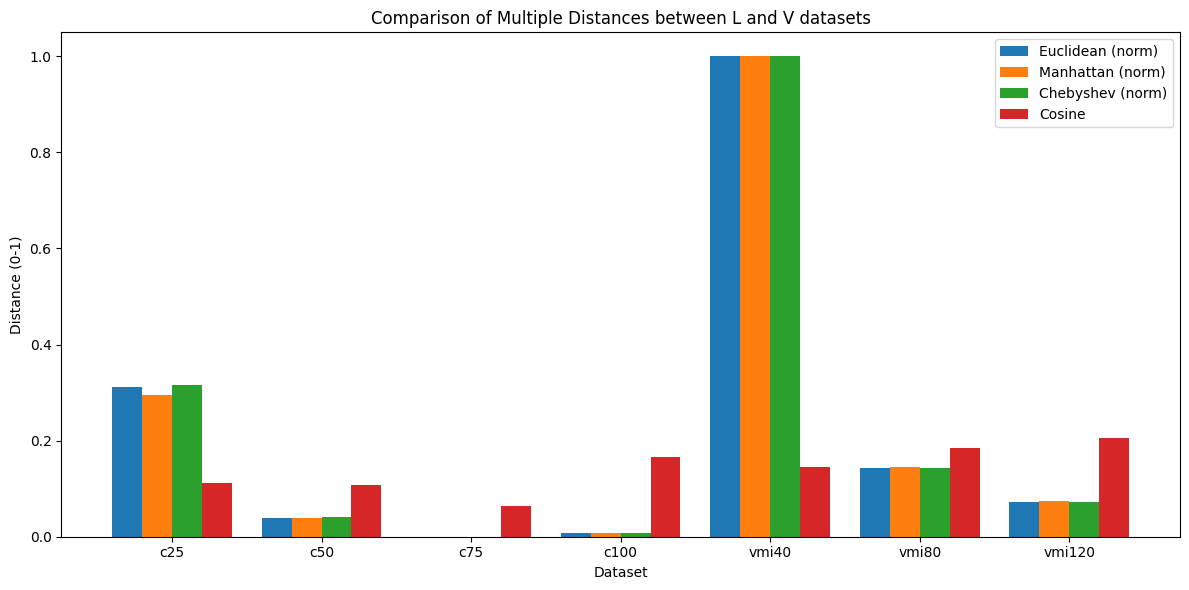

In [106]:
# Visualization
x = np.arange(len(names))
width = 0.2

fig, ax = plt.subplots(figsize=(12,6))

rects1 = ax.bar(x - 1.5*width, eucl_norm, width, label='Euclidean (norm)')
rects2 = ax.bar(x - 0.5*width, manh_norm, width, label='Manhattan (norm)')
rects3 = ax.bar(x + 0.5*width, cheb_norm, width, label='Chebyshev (norm)')
rects4 = ax.bar(x + 1.5*width, cos_distances, width, label='Cosine')

ax.set_ylabel('Distance (0-1)')
ax.set_xlabel('Dataset')
ax.set_title('Comparison of Multiple Distances between L and V datasets')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()

plt.tight_layout()
plt.show()

🔵 Compare RMS of all image types

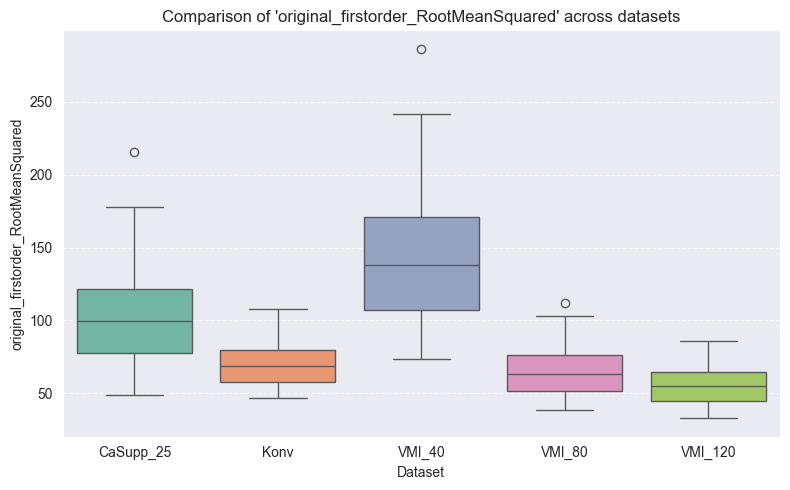

In [17]:
def standardize_df(df):
    scaler = StandardScaler()
    numeric_cols = df.select_dtypes(include=["number"]).columns
    df_scaled = pd.DataFrame(scaler.fit_transform(df[numeric_cols]), columns=numeric_cols, index=df.index)
    return df_scaled


# RMS for lesions datasets

# not standardized df
df_c25 = pd.read_csv(r"D:\CSV\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
df_konv = pd.read_csv(r"D:\CSV\merged_konv_radiomics_spine_lesions_features.csv")
df_vmi40 = pd.read_csv(r"D:\CSV\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
df_vmi80 = pd.read_csv(r"D:\CSV\merged_monoe_80kev_radiomics_spine_lesions_features.csv")
df_vmi120 = pd.read_csv(r"D:\CSV\merged_monoe_120kev_radiomics_spine_lesions_features.csv")

# df_c25 = pd.read_csv(r"D:\CSV\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv")
# df_konv = pd.read_csv(r"D:\CSV\merged_konv_radiomics_spine_vertebrae_features.csv")
# df_vmi40 = pd.read_csv(r"D:\CSV\merged_monoe_40kev_radiomics_spine_vertebrae_features.csv")
# df_vmi80 = pd.read_csv(r"D:\CSV\merged_monoe_80kev_radiomics_spine_vertebrae_features.csv")
# df_vmi120 = pd.read_csv(r"D:\CSV\merged_monoe_120kev_radiomics_spine_vertebrae_features.csv")

# standardized df
# df_c25 = standardize_df(df_c25)
# df_konv = standardize_df(df_konv)
# df_vmi40 = standardize_df(df_vmi40)
# df_vmi80 = standardize_df(df_vmi80)
# df_vmi120 = standardize_df(df_vmi120)

feature_name = "original_firstorder_RootMeanSquared"

data = pd.DataFrame({
    "Dataset": [
        "CaSupp_25"] * len(df_c25) +
        ["Konv"] * len(df_konv) +
        ["VMI_40"] * len(df_vmi40) +
        ["VMI_80"] * len(df_vmi80) +
        ["VMI_120"] * len(df_vmi120),
    "Feature Value": (
        list(df_c25[feature_name]) +
        list(df_konv[feature_name]) +
        list(df_vmi40[feature_name]) +
        list(df_vmi80[feature_name]) +
        list(df_vmi120[feature_name])
    )
})

plt.figure(figsize=(8,5))
sns.boxplot(x="Dataset", y="Feature Value", data=data, palette="Set2", hue="Dataset")
plt.title(f"Comparison of '{feature_name}' across datasets")
plt.xlabel("Dataset")
plt.ylabel(feature_name)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

🔵 Compare RMS of all image types standardized by ROI feature (variance, std)

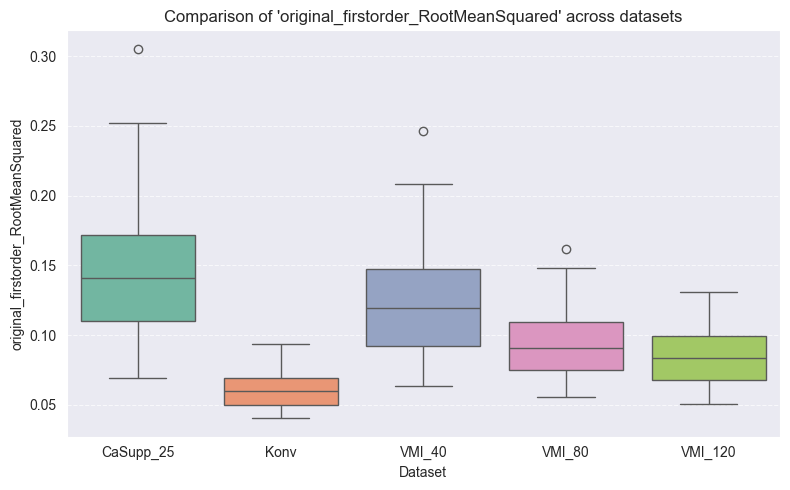

In [11]:
def standardization_feature(image):
    # Define ROI
    z_min, z_max = 60, 120  # TUK       450-500 LIVER       580-650 LUNGS
    y_min, y_max = 405, 420 # TUK       250-300 LIVER       240-300 LUNGS
    x_min, x_max = 200, 350 # TUK       150-200 LIVER       360-400 LUNGS

    # Compute selected feature of ROI
    return np.var(image[x_min:x_max, y_min:y_max, z_min:z_max])


# Load datasets
# df_c25 = pd.read_csv(r"D:\CSV\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv")
# df_konv = pd.read_csv(r"D:\CSV\merged_konv_radiomics_spine_vertebrae_features.csv")
# df_vmi40 = pd.read_csv(r"D:\CSV\merged_monoe_40kev_radiomics_spine_vertebrae_features.csv")
# df_vmi80 = pd.read_csv(r"D:\CSV\merged_monoe_80kev_radiomics_spine_vertebrae_features.csv")
# df_vmi120 = pd.read_csv(r"D:\CSV\merged_monoe_120kev_radiomics_spine_vertebrae_features.csv")

df_c25 = pd.read_csv(r"D:\CSV\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
df_konv = pd.read_csv(r"D:\CSV\merged_konv_radiomics_spine_lesions_features.csv")
df_vmi40 = pd.read_csv(r"D:\CSV\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
df_vmi80 = pd.read_csv(r"D:\CSV\merged_monoe_80kev_radiomics_spine_lesions_features.csv")
df_vmi120 = pd.read_csv(r"D:\CSV\merged_monoe_120kev_radiomics_spine_lesions_features.csv")

# Load images
c25 = NiftiFile(r"D:\DATA_Myelomy\Myel_001\myel_001_CaSupp_25.nii.gz").get_image_data()
konv = NiftiFile(r"D:\DATA_Myelomy\Myel_001\myel_001_konv.nii.gz").get_image_data()
vmi40 = NiftiFile(r"D:\DATA_Myelomy\Myel_001\myel_001_monoe_40kev.nii.gz").get_image_data()
vmi80 = NiftiFile(r"D:\DATA_Myelomy\Myel_001\myel_001_monoe_80kev.nii.gz").get_image_data()
vmi120 = NiftiFile(r"D:\DATA_Myelomy\Myel_001\myel_001_monoe_120kev.nii.gz").get_image_data()

feature_name = "original_firstorder_RootMeanSquared"

data = pd.DataFrame({
    "Dataset": [
        "CaSupp_25"] * len(df_c25) +
        ["Konv"] * len(df_konv) +
        ["VMI_40"] * len(df_vmi40) +
        ["VMI_80"] * len(df_vmi80) +
        ["VMI_120"] * len(df_vmi120),
    "Feature Value": (
        list(df_c25[feature_name]/standardization_feature(c25)) +
        list(df_konv[feature_name]/standardization_feature(konv)) +
        list(df_vmi40[feature_name]/standardization_feature(vmi40)) +
        list(df_vmi80[feature_name]/standardization_feature(vmi80)) +
        list(df_vmi120[feature_name]/standardization_feature(vmi120))
    )
})

plt.figure(figsize=(8,5))
sns.boxplot(x="Dataset", y="Feature Value", data=data, palette="Set2", hue="Dataset")
plt.title(f"Comparison of '{feature_name}' across datasets")
plt.xlabel("Dataset")
plt.ylabel(feature_name)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

🔵 Load lesions csv

In [ ]:
c25_l = pd.read_csv(r"D:\CSV\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
vmi40_l = pd.read_csv(r"D:\CSV\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
vmi80_l = pd.read_csv(r"D:\CSV\merged_monoe_80kev_radiomics_spine_lesions_features.csv")
vmi120_l = pd.read_csv(r"D:\CSV\merged_monoe_120kev_radiomics_spine_lesions_features.csv")
konv_l = pd.read_csv(r"D:\CSV\merged_konv_radiomics_spine_lesions_features.csv")

print(c25_l.shape == konv_l.shape == vmi40_l.shape == vmi80_l.shape == vmi120_l.shape)
konv_l.head()

🔵 Load vertebrae csv

In [ ]:
c25_v = pd.read_csv(r"D:\CSV\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv")
vmi40_v = pd.read_csv(r"D:\CSV\merged_monoe_40kev_radiomics_spine_vertebrae_features.csv")
vmi80_v = pd.read_csv(r"D:\CSV\merged_monoe_80kev_radiomics_spine_vertebrae_features.csv")
vmi120_v = pd.read_csv(r"D:\CSV\merged_monoe_120kev_radiomics_spine_vertebrae_features.csv")
konv_v = pd.read_csv(r"D:\CSV\merged_konv_radiomics_spine_vertebrae_features.csv")

print(c25_v.shape == konv_v.shape == vmi40_v.shape == vmi80_v.shape == vmi120_v.shape)
konv_v.head()

🔵 Comparison of every feature within datasets pair

In [ ]:
df1, df2 = c25_l, c25_v

common_features = df1.select_dtypes(include=['float64', 'int64']).columns.intersection(df2.select_dtypes(include=['float64', 'int64']).columns)

for feature in common_features:
    if "shape" in feature:
        continue

    data = pd.DataFrame({
        feature: pd.concat([df1[feature], df2[feature]], ignore_index=True),
        'Dataset': ['Lesions df']*len(df1) + ['Vertebrae df']*len(df2)
    }).dropna()

    plt.figure(figsize=(6,4))
    sns.boxplot(x='Dataset', y=feature, data=data, hue='Dataset', palette=['skyblue', 'salmon'], dodge=False, legend=False)
    plt.title(f'Comparison: {feature}')
    plt.ylabel(feature)
    plt.show()

🔵 Comparison of every feature within all datasets together

In [ ]:
pairs = [(c25_l, c25_v), (vmi40_l, vmi40_v), (vmi80_l, vmi80_v), (vmi120_l, vmi120_v), (konv_l, konv_v)]
names = [("c25_l", "c25_v"), ("vmi40_l", "vmi40_v"), ("vmi80_l", "vmi80_v"), ("vmi120_l", "vmi120_v"), ("konv_l", "konv_v")]

common_features = set(pairs[0][0].select_dtypes(include=['float64','int64']).columns) & set(pairs[0][1].select_dtypes(include=['float64','int64']).columns)
for df_a, df_b in pairs[1:]:
    cols_a = set(df_a.select_dtypes(include=['float64','int64']).columns)
    cols_b = set(df_b.select_dtypes(include=['float64','int64']).columns)
    common_features &= cols_a & cols_b

for feature in common_features:
    if "shape" in feature:
        continue

    data_list = []
    for i, ((df_a, df_b), (name_a, name_b)) in enumerate(zip(pairs, names), start=1):

        temp_a = pd.DataFrame({
        'Feature': df_a[feature],
        'Dataset': name_a
        })
        temp_b = pd.DataFrame({
            'Feature': df_b[feature],
            'Dataset': name_b
        })

        data_list.append(temp_a)
        data_list.append(temp_b)

    data_all = pd.concat(data_list).dropna()

    plt.figure(figsize=(12,5))
    sns.boxplot(x='Dataset', y='Feature', data=data_all, hue='Dataset', palette='tab10', dodge=False, legend=False)
    plt.title(f'Compare: {feature} through all dfs')
    plt.ylabel(feature)
    plt.xticks(rotation=45)
    plt.show()

🔵 Mann-Whitney U test between features within dataset pair

In [ ]:
df1, df2 = konv_l, konv_v

common_features = df1.select_dtypes(include=['float64','int64']).columns.intersection(df2.select_dtypes(include=['float64','int64']).columns)

results = {}

for feature in common_features:
    if "shape" in feature:
        continue
    group1 = df1[feature].dropna()
    group2 = df2[feature].dropna()

    u_stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
    results[feature] = {'U_stat': u_stat, 'p_value': p_value}

t_test_df = pd.DataFrame(results).T
significant_features = t_test_df[t_test_df['p_value'] < 0.05].sort_values('p_value')

print("Štatisticky významné rozdiely podľa Mann-Whitney U testu:")
print(significant_features)